<a href="https://colab.research.google.com/github/lakeshinisree/ML-Lab/blob/main/ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [5]:
!pip install ucimlrepo

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    balanced_accuracy_score
)

In [8]:
# Load Phishing Websites Dataset
phishing = fetch_ucirepo(id=327)

X = phishing.data.features
y = phishing.data.targets

print("Dataset loaded successfully!")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset loaded successfully!
Features: (11055, 30)
Target: (11055, 1)


In [9]:
df = pd.concat([X, y], axis=1)

print(df.head())
print("\nDataset Shape:", df.shape)

   having_ip_address  url_length  shortining_service  having_at_symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  prefix_suffix  having_sub_domain  sslfinal_state  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   domain_registration_length  favicon  ...  popupwindow  iframe  \


In [10]:
print(y.value_counts())

result
 1        6157
-1        4898
Name: count, dtype: int64


In [11]:
y = y.iloc[:, 0]

# 1 = Phishing
# 0 = Legitimate
y = y.map({-1: 1, 1: 0})

print(y.value_counts())

result
0    6157
1    4898
Name: count, dtype: int64


In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Predictions generated successfully!")

Model trained successfully!
Predictions generated successfully!


Confusion Matrix:
[[1169   62]
 [  97  883]]


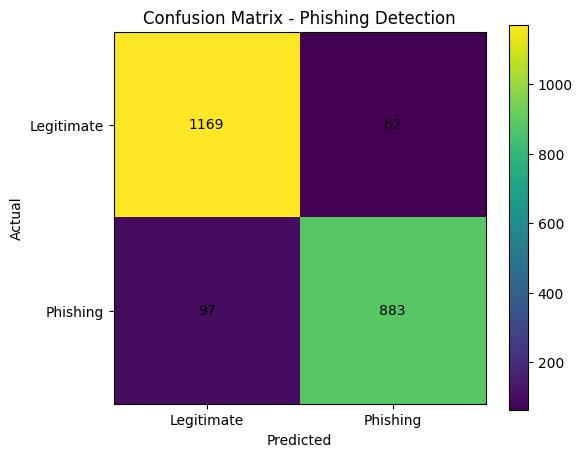

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - Phishing Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Additional metrics
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

# Display results
print("Classification Performance Metrics")
print("----------------------------------")
print(f"Accuracy            : {accuracy * 100:.2f}%")
print(f"Precision           : {precision * 100:.2f}%")
print(f"Recall              : {recall * 100:.2f}%")
print(f"F1-Score            : {f1 * 100:.2f}%")
print(f"Specificity         : {specificity * 100:.2f}%")
print(f"False Positive Rate : {fpr * 100:.2f}%")
print(f"False Negative Rate : {fnr * 100:.2f}%")
print(f"Balanced Accuracy   : {balanced_accuracy * 100:.2f}%")

Classification Performance Metrics
----------------------------------
Accuracy            : 92.81%
Precision           : 93.44%
Recall              : 90.10%
F1-Score            : 91.74%
Specificity         : 94.96%
False Positive Rate : 5.04%
False Negative Rate : 9.90%
Balanced Accuracy   : 92.53%


ROC-AUC Score: 0.979


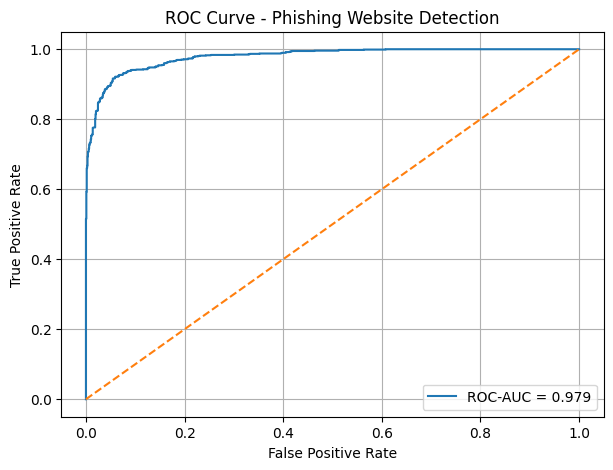

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 3))

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Phishing Website Detection")

plt.legend()
plt.grid()

plt.show()